# LangGraph Fundamentals — From Zero to Graphs

## What You'll Learn

LangGraph is a framework for building **stateful, multi-step AI applications** as directed graphs.
Instead of chaining function calls manually, you declare a graph of **nodes** (steps) and **edges** (transitions),
and LangGraph handles orchestration, state management, and control flow.

This notebook covers every core concept you need:

| Concept | What It Does |
|---|---|
| **State** | Shared data container (TypedDict) that flows through the graph |
| **Node** | A Python function that reads state and returns updates |
| **Edge** | A connection between nodes (linear flow) |
| **Conditional Edge** | A branch — picks the next node based on state |
| **Loop (Cycle)** | A node that routes back to a previous node |
| **Routing** | Dynamic multi-path selection based on state |

No LLM is needed for most examples — we'll add one at the end.

In [1]:
import sys
import operator
sys.path.append('..')

from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from IPython.display import Image, display


def show_graph(runnable):
    """Render the LangGraph graph as a Mermaid diagram."""
    try:
        display(Image(runnable.get_graph().draw_mermaid_png()))
    except Exception:
        print(runnable.get_graph().draw_mermaid())


print("LangGraph imported successfully \u2713")

LangGraph imported successfully ✓


## Project Structure

All notebooks in this repo share a set of utility modules in the parent directory:

| Module | Purpose |
|---|---|
| `utils/` | LLM provider factory (`create_llm_provider`), config loader (`get_config`), token counter |
| `rag_internal/` | Internal RAG retriever backed by Qdrant — represents *agent memory*, not a tool |
| `tools/` | External tools: `web_search` (Tavily) and `booking_tool` (local JSON lookup) |
| `config/` | `models.yaml` and `params.yaml` — provider, model, and RAG settings |
| `data/` | Medical knowledge `.txt` files for RAG and `bookings.json` for the booking tool |

This notebook uses only `utils/` (LangGraph concepts don't require RAG or tools). Later notebooks add `rag_internal/` and `tools/` as the patterns grow more complex.

## Why Graphs?

Traditional code runs top-to-bottom. But agent workflows are **non-linear**:

- An agent might loop back to re-think after observing a result
- A router might send different queries to different specialists
- A self-critique loop might exit early when quality is sufficient

Graphs give you:
1. **Explicit control flow** — you can *see* the workflow
2. **Cycles** — loops are first-class (unlike DAG-only pipelines)
3. **State management** — data flows through a typed container
4. **Composability** — graphs can be nested inside other graphs

---

## Core Concept #1: State

**State** is the shared data container that every node reads from and writes to.
It's defined as a Python `TypedDict` — a dictionary with typed keys.

Think of it as the agent's **working memory** that gets updated at each step.

```python
class MyState(TypedDict):
    message: str
    count: int
```

**Key rule:** Nodes return a *partial* dict with only the fields they want to update.
LangGraph merges the update into the existing state.

In [2]:
class SimpleState(TypedDict):
    message: str
    word_count: int

initial = SimpleState(message="Hello LangGraph!", word_count=0)
print(f"Initial state: {initial}")
print(f"Type: {type(initial)}")
print(f"It's just a dict: {isinstance(initial, dict)}")

Initial state: {'message': 'Hello LangGraph!', 'word_count': 0}
Type: <class 'dict'>
It's just a dict: True


---

## Core Concept #2: Nodes

A **Node** is any Python function that:
1. Takes the current `state` dict as its argument
2. Returns a **partial** state update (only the keys that changed)

LangGraph merges the returned dict into the existing state automatically.

```python
def my_node(state: MyState) -> dict:
    return {"count": state["count"] + 1}  # only update 'count'
```

Nodes are **regular Python functions** — no special decorators or base classes needed.

In [3]:
def count_words(state: SimpleState) -> dict:
    """Count words in the message."""
    words = len(state["message"].split())
    return {"word_count": words}

test_state = {"message": "Hello LangGraph world!", "word_count": 0}
result = count_words(test_state)
print(f"Input state:  {test_state}")
print(f"Node output:  {result}")
print("\nThe node returns ONLY the fields it updates.")
print("LangGraph merges this into the full state.")

Input state:  {'message': 'Hello LangGraph world!', 'word_count': 0}
Node output:  {'word_count': 3}

The node returns ONLY the fields it updates.
LangGraph merges this into the full state.


---

## Core Concept #3: Edges — Building Your First Graph

**Edges** connect nodes to define execution order. LangGraph provides two special markers:
- `START` — the entry point (where execution begins)
- `END` — the exit point (where execution stops)

### Building a graph in 5 steps:

```python
# 1. Create graph with state type
graph = StateGraph(MyState)

# 2. Add nodes
graph.add_node("name", function)

# 3. Add edges
graph.add_edge(START, "name")
graph.add_edge("name", END)

# 4. Compile
app = graph.compile()

# 5. Invoke
result = app.invoke(initial_state)
```

Result: {'message': 'Hello LangGraph world!', 'word_count': 3}

word_count was 0, now it's 3


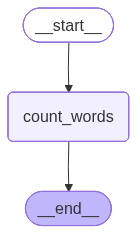

In [4]:
graph = StateGraph(SimpleState)

graph.add_node("count_words", count_words)

graph.add_edge(START, "count_words")
graph.add_edge("count_words", END)

app = graph.compile()

result = app.invoke({"message": "Hello LangGraph world!", "word_count": 0})
print(f"Result: {result}")
print(f"\nword_count was 0, now it's {result['word_count']}")

show_graph(app)

---

## Multi-Node Linear Chain

Real workflows have multiple steps. Let's build a three-node pipeline:

```
START → analyze → transform → format → END
```

Each node reads the state, does its work, and returns updates.

[SHORT | 2 words] short text
[LONG | 16 words] LANGGRAPH MAKES IT EASY TO BUILD STATEFUL MULTI-ST


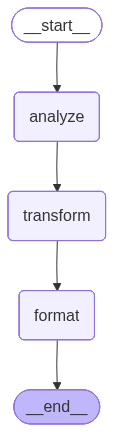

In [5]:
class PipelineState(TypedDict):
    text: str
    word_count: int
    is_long: bool
    summary: str


def analyze(state: PipelineState) -> dict:
    count = len(state["text"].split())
    return {"word_count": count, "is_long": count > 10}


def transform(state: PipelineState) -> dict:
    text = state["text"].upper() if state["is_long"] else state["text"].lower()
    return {"text": text}


def format_output(state: PipelineState) -> dict:
    label = "LONG" if state["is_long"] else "SHORT"
    return {"summary": f"[{label} | {state['word_count']} words] {state['text'][:50]}"}


graph = StateGraph(PipelineState)
graph.add_node("analyze", analyze)
graph.add_node("transform", transform)
graph.add_node("format", format_output)

graph.add_edge(START, "analyze")
graph.add_edge("analyze", "transform")
graph.add_edge("transform", "format")
graph.add_edge("format", END)

app = graph.compile()

for text in [
    "Short text",
    "LangGraph makes it easy to build stateful multi-step AI applications with clear control flow and cycles",
]:
    result = app.invoke({"text": text, "word_count": 0, "is_long": False, "summary": ""})
    print(result["summary"])

show_graph(app)

---

## Core Concept #4: Conditional Edges (Branching)

Not every workflow is linear. **Conditional edges** let you pick the next node based on the current state.

```python
graph.add_conditional_edges(
    "source_node",        # from this node...
    routing_function,      # call this function (returns a string key)...
    {                      # and map the key to the next node:
        "key_a": "node_a",
        "key_b": "node_b",
    }
)
```

The **routing function** inspects state and returns a string. The **path map** translates that string to a node name.

'Short doc...' -> Score: 0 -> REJECTED
  Score 0/10 is below threshold. Needs revision.

'This is a longer document that should ge...' -> Score: 1 -> REJECTED
  Score 1/10 is below threshold. Needs revision.



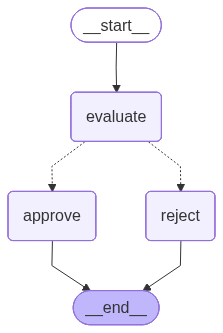

In [6]:
class ReviewState(TypedDict):
    document: str
    score: int
    decision: str
    feedback: str


def evaluate(state: ReviewState) -> dict:
    score = len(state["document"].split()) // 10
    return {"score": score}


def approve(state: ReviewState) -> dict:
    return {
        "decision": "APPROVED",
        "feedback": f"Score {state['score']}/10 meets threshold. Approved.",
    }


def reject(state: ReviewState) -> dict:
    return {
        "decision": "REJECTED",
        "feedback": f"Score {state['score']}/10 is below threshold. Needs revision.",
    }


def route_by_score(state: ReviewState) -> str:
    """Routing function — returns the KEY for the path map."""
    if state["score"] >= 5:
        return "approve"
    return "reject"


graph = StateGraph(ReviewState)
graph.add_node("evaluate", evaluate)
graph.add_node("approve", approve)
graph.add_node("reject", reject)

graph.add_edge(START, "evaluate")
graph.add_conditional_edges("evaluate", route_by_score, {
    "approve": "approve",
    "reject": "reject",
})
graph.add_edge("approve", END)
graph.add_edge("reject", END)

app = graph.compile()

for doc in ["Short doc", "This is a longer document that should get a higher score from the evaluator"]:
    result = app.invoke({"document": doc, "score": 0, "decision": "", "feedback": ""})
    print(f"'{doc[:40]}...' -> Score: {result['score']} -> {result['decision']}")
    print(f"  {result['feedback']}\n")

show_graph(app)

---

## Core Concept #5: Loops (Cycles)

Unlike DAG-only pipelines, LangGraph supports **cycles** — a node can route back to itself or a previous node.

This is essential for agentic patterns:
- Reflection loops (critique → revise → critique again)
- ReAct loops (think → act → observe → think again)
- Retry logic (try → check → retry)

```
START → increment ─┐
           ↑        │
           └────────┘  (loop until value >= 5)
                    │
                    └→ END
```

Final value: 5
History:     [1, 2, 3, 4, 5]
Iterations:  5

Notice: increment() returns [new_val] each time.
LangGraph's Annotated[list, operator.add] reducer concatenates them automatically.


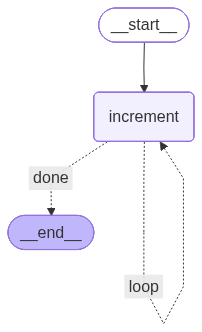

In [7]:
class CounterState(TypedDict):
    value: int
    # Annotated[list, operator.add] tells LangGraph to APPEND instead of replace.
    # Each node returns a partial list; LangGraph accumulates them automatically.
    # You will see this same pattern in the ReAct and Multi-Agent notebooks.
    history: Annotated[list, operator.add]


def increment(state: CounterState) -> dict:
    new_val = state["value"] + 1
    return {
        "value": new_val,
        "history": [new_val],  # return just the new item — the add reducer appends it
    }


def should_continue(state: CounterState) -> str:
    """Loop back to 'increment' until value reaches 5."""
    if state["value"] >= 5:
        return "done"
    return "loop"


graph = StateGraph(CounterState)
graph.add_node("increment", increment)

graph.add_edge(START, "increment")
graph.add_conditional_edges("increment", should_continue, {
    "loop": "increment",
    "done": END,
})

app = graph.compile()

result = app.invoke({"value": 0, "history": []})
print(f"Final value: {result['value']}")
print(f"History:     {result['history']}")
print(f"Iterations:  {len(result['history'])}")
print()
print("Notice: increment() returns [new_val] each time.")
print("LangGraph's Annotated[list, operator.add] reducer concatenates them automatically.")

show_graph(app)

---

## Putting It Together: LLM-Powered Routing

Let's combine everything into a real-world example: an **LLM-powered router** that classifies a user query and routes it to the appropriate handler.

```
START → classify → ┬─ handle_medical   ─┬→ END
                    ├─ handle_logistics  ─┤
                    └─ handle_general    ─┘
```

This uses the project's `create_llm_provider()` — same LLM you'll use in the pattern notebooks.

**If you see `InternalServerError` (500):** OpenRouter or the model provider may be temporarily unavailable. The code retries up to 5 times with backoff. If it still fails, re-run the cell in a few minutes or check [OpenRouter status](https://openrouter.ai/docs#status).

In [8]:
from utils import create_llm_provider, get_config

config = get_config()
llm = create_llm_provider()

print(f"Using model: {config.get('model')}")

Using model: openai/gpt-4o-mini


Query:    What are the symptoms of diabetes?
Category: medical
Response: Common symptoms of diabetes include increased thirst, frequent urination, extreme fatigue, blurred vision, and slow-healing sores or frequent infections. Some people may also experience unexplained we...
------------------------------------------------------------
Query:    What are the visiting hours at Nawaloka Hospital?
Category: logistics
Response: Visiting hours at Nawaloka Hospital typically vary by department, but generally, they are from 10:00 AM to 12:00 PM and 4:00 PM to 7:00 PM. It's advisable to check with the hospital directly for any s...
------------------------------------------------------------
Query:    What's the weather like today?
Category: general
Response: I'm sorry, but I can't provide real-time weather updates. You can check a weather website or app for the most current information....
------------------------------------------------------------


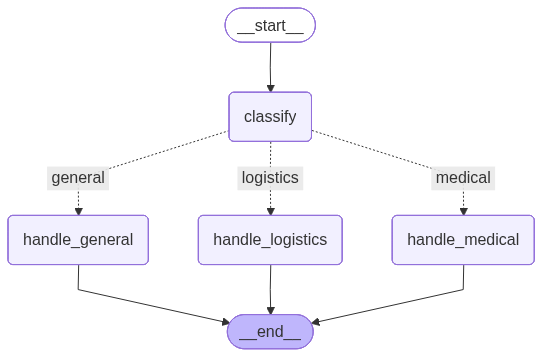

In [9]:
class RouterState(TypedDict):
    query: str
    category: str
    response: str


def classify(state: RouterState) -> dict:
    result = llm.generate(
        prompt=(
            f"Classify this query into exactly one category: medical, logistics, or general.\n\n"
            f"medical - only handle questions about medical stuffs\n"
             "logistics - only handle logistics and basic hospital stuff\n"
             "general - only handle questions about general stuff\n"
            f"Query: {state['query']}\n\n"
            f"Respond with ONLY the category name (one word)."
        ),
        system_prompt="You are a query classifier. Respond with exactly one word: medical, logistics, or general.",
    )
    category = result["response"].strip().lower()
    if category not in ("medical", "logistics", "general"):
        category = "general"
    return {"category": category}


def handle_medical(state: RouterState) -> dict:
    result = llm.generate(
        prompt=state["query"],
        system_prompt="You are a medical information assistant. Provide a brief, helpful answer (2-3 sentences).",
    )
    return {"response": result["response"]}


def handle_logistics(state: RouterState) -> dict:
    result = llm.generate(
        prompt=state["query"],
        system_prompt="You are a hospital logistics assistant. Provide operational information briefly (2-3 sentences).",
    )
    return {"response": result["response"]}


def handle_general(state: RouterState) -> dict:
    result = llm.generate(
        prompt=state["query"],
        system_prompt="You are a helpful assistant. Provide a brief answer (2-3 sentences).",
    )
    return {"response": result["response"]}


def route_query(state: RouterState) -> str:
    return state["category"]


graph = StateGraph(RouterState)
graph.add_node("classify", classify)
graph.add_node("handle_medical", handle_medical)
graph.add_node("handle_logistics", handle_logistics)
graph.add_node("handle_general", handle_general)

graph.add_edge(START, "classify")
graph.add_conditional_edges("classify", route_query, {
    "medical": "handle_medical",
    "logistics": "handle_logistics",
    "general": "handle_general",
})
graph.add_edge("handle_medical", END)
graph.add_edge("handle_logistics", END)
graph.add_edge("handle_general", END)

app = graph.compile()

queries = [
    "What are the symptoms of diabetes?",
    "What are the visiting hours at Nawaloka Hospital?",
    "What's the weather like today?",
]

for q in queries:
    result = app.invoke({"query": q, "category": "", "response": ""})
    print(f"Query:    {q}")
    print(f"Category: {result['category']}")
    print(f"Response: {result['response'][:200]}...")
    print("-" * 60)

show_graph(app)

---

## Summary

| Concept | What It Does | Key API |
|---|---|---|
| **State** | Shared typed data container | `TypedDict` |
| **Node** | Function that transforms state | `graph.add_node(name, fn)` |
| **Edge** | Fixed connection between nodes | `graph.add_edge(a, b)` |
| **Conditional Edge** | Branch based on state | `graph.add_conditional_edges(node, fn, map)` |
| **START / END** | Entry and exit points | `from langgraph.graph import START, END` |
| **Compile** | Turn graph definition into runnable | `app = graph.compile()` |
| **Invoke** | Execute the graph with initial state | `app.invoke(state)` |

### Key Takeaways

1. **State is central** — everything flows through the shared `TypedDict`
2. **Nodes are just functions** — any Python function that returns a partial state update
3. **Edges define flow** — linear, conditional, or cyclic
4. **Graphs compile** — turn your definition into an executable app
5. **LangGraph handles orchestration** — you focus on logic, LangGraph handles plumbing

### What's Next

Now that you know the building blocks, we'll use them to implement four agentic design patterns:

- **Notebook 01**: Reflection (self-critique loops)
- **Notebook 02**: Tool Use (web search integration)
- **Notebook 03**: ReAct / Planning (reasoning + acting)
- **Notebook 04**: Multi-Agent (parallel specialists)